In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# Load your CSV data into a DataFrame, replace 'your_data.csv' with your actual file path
df = pd.read_csv('/content/drive/MyDrive/CV/fitbit_data.csv')

In [14]:
df = pd.read_csv('/content/drive/MyDrive/CV/fitbit_data.csv', header=None, names=["Timestamp", "X", "Y", "Z"])


In [15]:
print(df.head())  # Displays the first 5 rows


    Timestamp      X      Y      Z
0  1332640128 -2.412  7.604  6.090
1  1332640128  0.038  6.742  7.296
2  1332640128  0.554  6.838  7.738
3  1332640128  0.708  6.568  7.546
4  1332640256  0.726  6.588  7.546


In [16]:
print(df.info())  # Overview of the dataset
print(df.isnull().sum())  # Count of missing values per column


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Timestamp  1080 non-null   int64  
 1   X          1080 non-null   float64
 2   Y          1080 non-null   float64
 3   Z          1080 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 33.9 KB
None
Timestamp    0
X            0
Y            0
Z            0
dtype: int64


In [17]:
print(df.describe())


          Timestamp            X            Y            Z
count  1.080000e+03  1080.000000  1080.000000  1080.000000
mean   1.332656e+09    -0.110730     6.322791     7.124533
std    9.415658e+03     2.451216     2.235440     2.487254
min    1.332640e+09   -14.594000    -6.760000   -18.138000
25%    1.332648e+09    -0.574000     5.056000     6.588000
50%    1.332656e+09     0.152000     6.885000     7.220000
75%    1.332664e+09     1.090000     7.470000     8.196000
max    1.332673e+09     8.120000    17.928000    15.668000


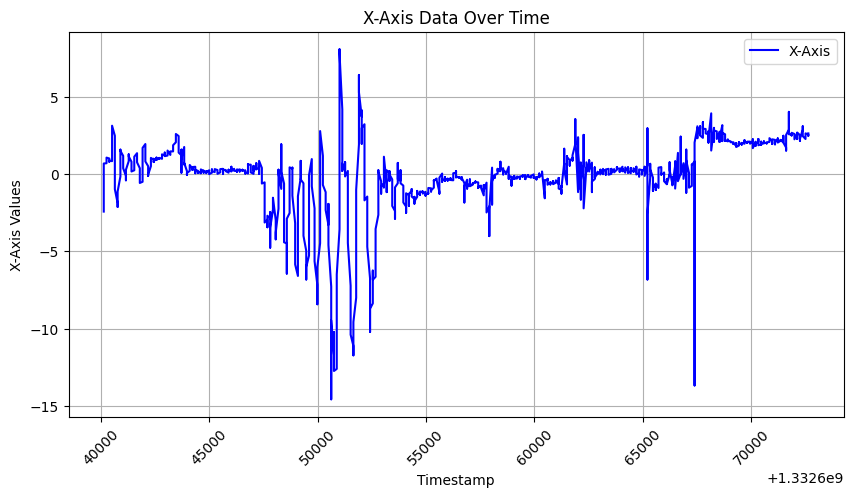

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(df['Timestamp'], df['X'], label='X-Axis', color='blue')
plt.xlabel('Timestamp')
plt.ylabel('X-Axis Values')
plt.title('X-Axis Data Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [19]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])


In [20]:
df = df[df['X'] > 0]  # Example: Keep rows where X > 0


In [21]:
mean_values = df[['X', 'Y', 'Z']].mean()
print(mean_values)


X    1.203808
Y    6.947496
Z    7.386550
dtype: float64


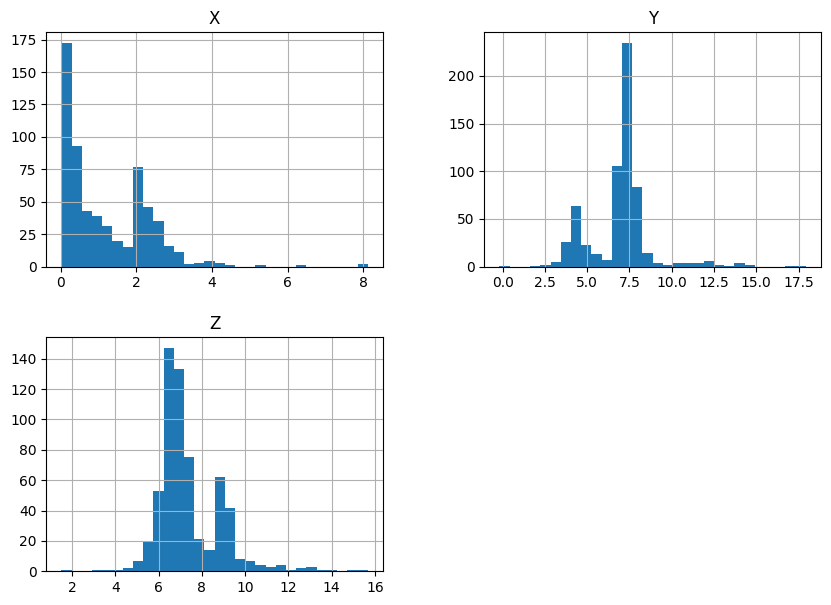

In [22]:
df[['X', 'Y', 'Z']].hist(bins=30, figsize=(10, 7))
plt.show()


In [24]:
print(df['Timestamp'].isnull().sum())  # Count missing values
print(df['Timestamp'].duplicated().sum())  # Count duplicates


0
441


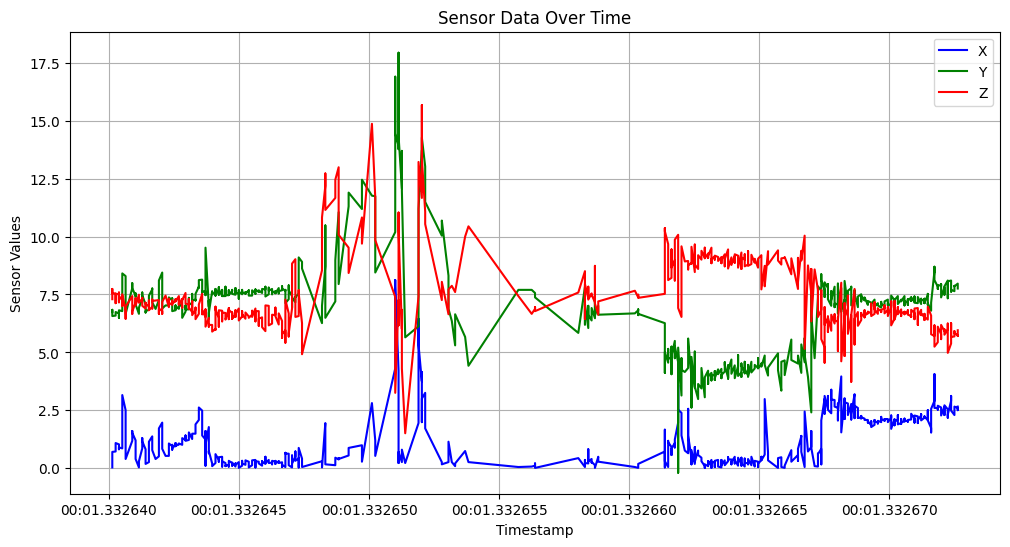

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(df['Timestamp'], df['X'], label='X', color='blue')
plt.plot(df['Timestamp'], df['Y'], label='Y', color='green')
plt.plot(df['Timestamp'], df['Z'], label='Z', color='red')
plt.xlabel('Timestamp')
plt.ylabel('Sensor Values')
plt.title('Sensor Data Over Time')
plt.legend()
plt.grid()
plt.show()


In [26]:
df['hour'] = df['Timestamp'].dt.hour
hourly_avg = df.groupby('hour')[['X', 'Y', 'Z']].mean()
print(hourly_avg)


             X         Y        Z
hour                             
0     1.203808  6.947496  7.38655


**Outliers**

In [23]:
outliers = df[df['X'] > df['X'].quantile(0.95)]  # Top 5% X values
print(outliers)


                         Timestamp      X       Y       Z
16   1970-01-01 00:00:01.332640512  3.160   8.408   7.508
362  1970-01-01 00:00:01.332651008  4.308  10.190   7.392
363  1970-01-01 00:00:01.332651008  8.120  16.894   7.200
364  1970-01-01 00:00:01.332651008  7.852  14.442   3.256
365  1970-01-01 00:00:01.332651136  4.212  13.904   7.258
391  1970-01-01 00:00:01.332651904  4.576   7.220   8.044
392  1970-01-01 00:00:01.332651904  6.454  10.380  10.860
393  1970-01-01 00:00:01.332651904  5.324  11.186  13.216
394  1970-01-01 00:00:01.332652032  3.754  13.714  11.664
395  1970-01-01 00:00:01.332652032  4.156  11.932  12.870
397  1970-01-01 00:00:01.332652032  3.390  13.024  14.154
398  1970-01-01 00:00:01.332652032  3.006  14.268  13.388
399  1970-01-01 00:00:01.332652160  3.256  13.024  11.070
722  1970-01-01 00:00:01.332661888  3.122  -0.190   8.522
723  1970-01-01 00:00:01.332661888  3.580   1.628   7.066
832  1970-01-01 00:00:01.332665216  2.988   4.462   7.852
907  1970-01-0

In [29]:
for col in ['X', 'Y', 'Z']:
    lower_bound = Q1[col] - 1.5 * IQR[col]
    upper_bound = Q3[col] + 1.5 * IQR[col]
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers in {col}:")
    print(outliers)


Outliers in X:
                        Timestamp      X       Y       Z  hour
363 1970-01-01 00:00:01.332651008  8.120  16.894   7.200     0
364 1970-01-01 00:00:01.332651008  7.852  14.442   3.256     0
392 1970-01-01 00:00:01.332651904  6.454  10.380  10.860     0
393 1970-01-01 00:00:01.332651904  5.324  11.186  13.216     0
Outliers in Y:
                        Timestamp      X       Y       Z  hour
122 1970-01-01 00:00:01.332643712  1.014   9.518   6.110     0
274 1970-01-01 00:00:01.332648320  1.914  10.476  12.718     0
288 1970-01-01 00:00:01.332648832  0.382  11.050  12.986     0
289 1970-01-01 00:00:01.332648832  0.440  10.150  11.874     0
302 1970-01-01 00:00:01.332649216  0.554  11.300   9.518     0
..                            ...    ...     ...     ...   ...
882 1970-01-01 00:00:01.332666752  0.056   4.576  10.036     0
884 1970-01-01 00:00:01.332666752  2.450   4.884   5.152     0
886 1970-01-01 00:00:01.332666880  0.726   3.944   8.752     0
890 1970-01-01 00:00:01.3